# 03 - Why it works: the leaderboard argument

> "You promised the desk 90%. Why should anyone believe a promise that holds for ANY model and ANY market?" — Hearthstone's head of acquisitions, after reading notebook 02's coverage report

It is the right question, and the answer sounds like a dodge until you see it demonstrated: the 90% is not a statement about models or markets at all. It is a statement about where a newcomer lands on a leaderboard of shuffled peers, and ranks do not care what the numbers mean. Once you believe that one sentence, everything notebook 02 did — the held-out scores, the strange quantile level, the refusal to touch training residuals — stops looking like ritual and starts looking inevitable.

This is the theory notebook of the series, and it contains no scary math. Every claim is demonstrated by simulation before (or instead of) being stated formally. **Split conformal prediction** — the fit-on-one-half, calibrate-on-the-other recipe from notebook 02 — is on trial here, and simulations are the witnesses.

What you will learn:

- where the coverage guarantee comes from: a rank argument you can simulate in four lines of numpy
- why the corrected quantile level `ceil((n+1)*(1-alpha))/n` is bookkeeping you cannot skip (field guide §1)
- what one calibration set actually buys you: a lottery ticket around the target, not the target itself (field guide §4)
- what the 90% average can hide slice by slice (field guide §3), and the one assumption that, once broken, voids everything without raising an error (field guide §6)

Where we are in the series: notebook 02 built split conformal in fifteen lines; this notebook explains why those fifteen lines are entitled to make promises. Notebook 04 aims the same machinery at classification.

In [1]:
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.ensemble import GradientBoostingRegressor

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
RANDOM_SEED = 20260707

BLUE, GREEN, AMBER, RED, GRAY, PURPLE = (
    "#2563EB", "#059669", "#F59E0B", "#DC2626", "#6B7280", "#7C3AED",
)

alpha = 0.10  # the series-wide error budget: we accept missing 1 listing in 10

## 1. Strip the problem naked

Before we defend the guarantee for a gradient-boosted model on four features, we strip the problem of everything inessential. No model. No features. Just 99 closed sale prices from some market, and a 100th sale closing tomorrow. The task: draw a line high enough that tomorrow's price falls below it 90% of the time.

Two words of vocabulary, both introduced back in notebook 01 and used throughout notebook 02. **Alpha** (also called the **miscoverage rate**) is the error budget we choose up front — here `alpha = 0.10`, meaning we accept being wrong once in ten; `1 - alpha` is the **target coverage**. **Coverage** is the fraction of new cases where our line (later: our interval) actually contains the truth.

If prices were a tidy bell curve, any statistics textbook would hand us a formula. So we will do the opposite: we simulate prices from a distribution built to be as un-textbook as possible — two humps and a heavy luxury tail — precisely to make the point that its shape will not matter.

population median: 280k$ | 99th percentile: 839k$ | max: 59,652k$
our 99 observed sales: min 178k$ | median 272k$ | max 1,181k$


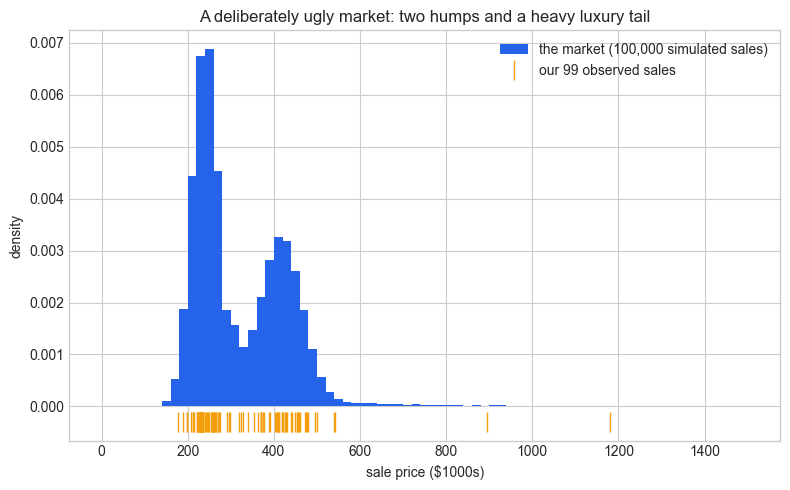

In [2]:
def simulate_ugly_prices(n, seed):
    """Sale prices (in $1000s) from a market we made ugly on purpose.

    Three ingredients, chosen to wreck every textbook assumption at once:
    - 55% ordinary homes around $240k (one bell curve),
    - 35% a pricier cluster around $420k (so the mix is bimodal, not normal),
    - 10% luxury sales with a Pareto tail (heavy-tailed: no finite variance).

    If the coverage argument survives THIS distribution, it is not
    borrowing anything from the distribution's shape.
    """
    rng = np.random.default_rng(seed)
    component = rng.choice(3, size=n, p=[0.55, 0.35, 0.10])
    ordinary = rng.normal(240.0, 30.0, size=n)
    pricier = rng.normal(420.0, 45.0, size=n)
    luxury = 300.0 + 150.0 * rng.pareto(1.5, size=n)
    return np.where(component == 0, ordinary, np.where(component == 1, pricier, luxury))


population = simulate_ugly_prices(100_000, seed=RANDOM_SEED)
observed = simulate_ugly_prices(99, seed=RANDOM_SEED + 1)

print(f"population median: {np.median(population):.0f}k$ | 99th percentile: "
      f"{np.percentile(population, 99):,.0f}k$ | max: {population.max():,.0f}k$")
print(f"our 99 observed sales: min {observed.min():.0f}k$ | "
      f"median {np.median(observed):.0f}k$ | max {observed.max():,.0f}k$")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(population, bins=np.linspace(0, 1500, 76), density=True, color=BLUE,
        label="the market (100,000 simulated sales)")
ax.plot(observed, np.full_like(observed, -0.0003), "|", color=AMBER,
        markersize=14, label="our 99 observed sales")
ax.set_title("A deliberately ugly market: two humps and a heavy luxury tail")
ax.set_xlabel("sale price ($1000s)")
ax.set_ylabel("density")
ax.legend()
plt.tight_layout()
plt.show()

The market has a median of 280k dollars, a 99th percentile near 839k, and — thanks to the Pareto ingredient — the occasional castle: the most expensive of 100,000 simulated sales tops 59 million (the plot is truncated at 1,500k so the humps stay visible; the tail continues far off-frame). Our 99 observed sales (the amber ticks) are a scruffy, gappy sample of this mess: they run from 178k to 1,181k with a median of 272k.

The claim we now have to earn: for the line-drawing task, none of this ugliness matters. Not the two humps, not the infinite-variance tail, not the gaps. The next section shows why.

## 2. The leaderboard argument

Here is the entire argument, told the way Shafer and Vovk tell it, with a bag of tiles.

Write each of the 100 sale prices — the 99 we observed and tomorrow's newcomer — on its own tile. Drop all 100 tiles into a bag and shake it. The shake destroys every trace of *which tile arrived when*. Now sort the tiles from cheapest to priciest into a leaderboard, positions 1 through 100, and ask: which position does the newcomer's tile hold?

If the 100 values are statistical peers — if their joint distribution does not care about the order they arrived in, so that "arrived last" carries no information — then the newcomer's tile is just one anonymous tile among 100. It is equally likely to be the cheapest, the 37th, or the priciest. In symbols, after the words: the newcomer's rank $r$ satisfies $\Pr(r = j) = \tfrac{1}{n+1}$ for every position $j$ from 1 to $n+1$, where $n = 99$ is the number of observed sales and rank means position on the sorted leaderboard, cheapest first.

That is the whole theorem. No bell curves, no variance, no model. Let us watch it happen: 10,000 simulated mornings, each with a fresh leaderboard of 100 prices from the ugly market, recording the newcomer's rank every time.

10,000 leaderboards of 100 prices each
expected count per rank if the theorem holds: 100
observed counts: min 76, mean 100, max 127


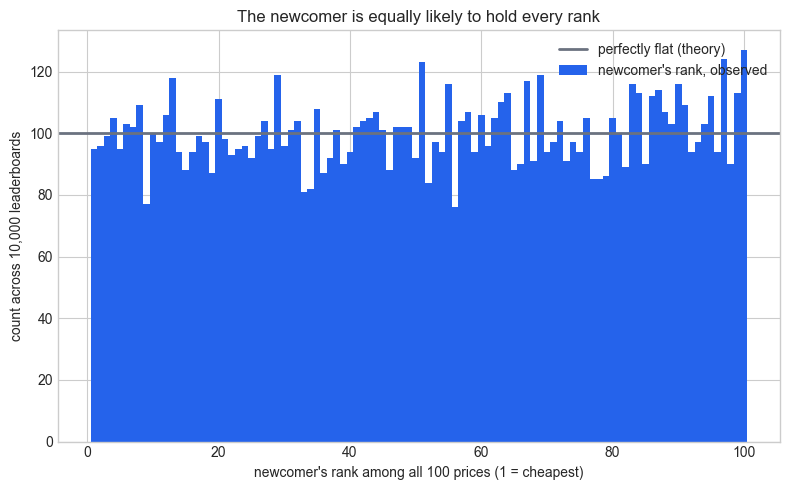

In [3]:
n = 99      # observed sales per leaderboard
R = 10_000  # simulated mornings, each with a fresh leaderboard of n+1 = 100 prices
draws = simulate_ugly_prices((n + 1) * R, seed=RANDOM_SEED + 2).reshape(R, n + 1)

# Column -1 plays the newcomer. Its rank = how many of the 100 prices sit at or below it.
ranks = (draws <= draws[:, -1:]).sum(axis=1)

counts = np.bincount(ranks, minlength=n + 2)[1:]
print(f"{R:,} leaderboards of {n + 1} prices each")
print(f"expected count per rank if the theorem holds: {R / (n + 1):.0f}")
print(f"observed counts: min {counts.min()}, mean {counts.mean():.0f}, max {counts.max()}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(np.arange(1, n + 2), counts, width=1.0, color=BLUE, label="newcomer's rank, observed")
ax.axhline(R / (n + 1), color=GRAY, lw=2, label="perfectly flat (theory)")
ax.set_title("The newcomer is equally likely to hold every rank")
ax.set_xlabel("newcomer's rank among all 100 prices (1 = cheapest)")
ax.set_ylabel(f"count across {R:,} leaderboards")
ax.legend()
plt.tight_layout()
plt.show()

Flat. Every rank was hit close to the expected 100 times — the counts run from 76 to 127, which is exactly the wobble you expect from 10,000 tosses spread over 100 bins, with no rank systematically favored. This flatness IS the coverage theorem; everything else in conformal prediction is bookkeeping on top of it.

Be precise about what the flat histogram does and does not say. It does not say prices are uniformly distributed — they are emphatically not; you saw the two humps and the tail in section 1. It says the newcomer's *rank* is uniform. Ranks are blind to the values written on the tiles, which is precisely why the ugly shape of the market never entered the argument. And note the one thing we did assume: the newcomer was a peer of the other 99, not a tile slipped into the bag from a different market. That assumption gets a name in section 4 and gets deliberately broken in section 7.

## 3. From ranks to the corrected quantile

Now turn the flat histogram into a line-drawing rule. Read it off directly: the newcomer's rank among all 100 tiles is at most $k$ with probability exactly $k/100$ — in general $k/(n+1)$ — because that is $k$ equally likely positions out of $n+1$.

One small translation step, because tomorrow morning we will only hold 99 tiles, not 100: the newcomer's rank among all 100 is at most $k$ exactly when at most $k-1$ of the 99 observed prices undercut it — that is, exactly when the newcomer sits at or below the $k$-th smallest of the 99 observed prices. So the event we can bet on tonight ("newcomer will fall at or below our $k$-th smallest observed price") has probability exactly $k/(n+1)$, computable before the newcomer exists.

We want that probability to be at least 0.90, so we take the smallest $k$ with $k/(n+1) \ge 1 - \alpha$: in words, $k$ is $(n+1)(1-\alpha)$ rounded up, $k = \lceil (n+1)(1-\alpha) \rceil$. With $n = 99$ and $\alpha = 0.10$ that is $k = \lceil 90 \rceil = 90$: use the 90th smallest of the 99 observed prices. This order statistic is what **the corrected quantile** from notebook 02 targets — "corrected" because it reserves the $+1$ seat at the table for the not-yet-seen newcomer. The notebook-02 idiom, which we revisit right after the simulation, never lands below this order statistic; occasionally it sits one observed score higher, which only makes the promise safer.

You will be tempted to reach for `np.quantile(observed, 0.9)` instead — the plain 90% sample quantile of the 99 prices. That rule interpolates around the 89th smallest price, one seat short, and its coverage sits just below the promise. The difference looks cosmetic. It is not, and it is worst exactly when your calibration set is small (field guide §1). Let us run both rules 100,000 times.

In [4]:
k = math.ceil((n + 1) * (1 - alpha))  # ceil(100 * 0.90) = 90
R = 100_000
draws = simulate_ugly_prices((n + 1) * R, seed=RANDOM_SEED + 3).reshape(R, n + 1)
cal, newcomer = draws[:, :n], draws[:, n]

# Corrected rule: the k-th smallest of the 99 observed prices.
# (np.partition guarantees only that column k-1 holds the k-th smallest of
#  each row - cheaper than a full sort, which is all we need.)
corrected_line = np.partition(cal, k - 1, axis=1)[:, k - 1]

# Naive rule: the plain 90% sample quantile of the same 99 prices.
naive_line = np.quantile(cal, 1 - alpha, axis=1)

print(f"k = ceil((n+1)*(1-alpha)) = ceil({(n + 1) * (1 - alpha):.0f}) = {k}"
      f" -> use the {k}-th smallest of the {n} observed prices")
print(f"corrected rule: newcomer fell at or below the line in "
      f"{(newcomer <= corrected_line).mean():.4f} of {R:,} trials")
print(f"naive rule:     newcomer fell at or below the line in "
      f"{(newcomer <= naive_line).mean():.4f} of {R:,} trials")
print(f"theory for the corrected rule: exactly k/(n+1) = {k / (n + 1):.4f}")

k = ceil((n+1)*(1-alpha)) = ceil(90) = 90 -> use the 90-th smallest of the 99 observed prices
corrected rule: newcomer fell at or below the line in 0.8998 of 100,000 trials
naive rule:     newcomer fell at or below the line in 0.8915 of 100,000 trials
theory for the corrected rule: exactly k/(n+1) = 0.9000


The corrected rule lands at 0.8998 — within Monte Carlo noise of the theoretical 0.9000. The naive rule lands at 0.8915, reliably below the promise: a gap of 0.0083, far beyond what 100,000 trials can produce by luck. One seat at the table, silently unreserved, and the 90% promise becomes an 89% delivery. At $n = 999$ the naive shortfall shrinks to a rounding error; at $n = 19$ it would be a scandal.

In the series' production code the corrected quantile is always grabbed with the notebook-02 idiom:

```python
n = len(scores)
q_level = math.ceil((n + 1) * (1 - alpha)) / n
q_hat = np.quantile(scores, q_level, method="higher")
```

Note the level is `90/99`, roughly 0.909 — not 0.90 — and `method="higher"` rounds up to an actually-observed sorted score rather than interpolating below it. Rounding down between sorted scores is precisely the naive mistake we just quantified, so the idiom never lands below the $k$-th smallest score that the rank argument demands. It is not always equal to it, either: numpy's quantile grid can land one sorted score higher than the exact rank — at $n = 99$ the idiom returns the 91st smallest, not the 90th — buying up to one extra seat of conservatism. The at-least side of the promise is what matters, and the idiom only ever errs on the safe side of it.

One more thing the rank argument gives us for free: an upper bound — for the exact $k$-th smallest score, the order statistic our simulations here take with `np.partition`, not for the idiom. The newcomer's rank is at most $k$ with probability *exactly* $k/(n+1)$, and since $k$ is a ceiling, that exact value can never reach $1 - \alpha + 1/(n+1)$. In words: the exact rule's coverage is sandwiched — at least the promise, and at most the promise plus one seat's worth, $1/(n+1)$. That rule is honest, not conservative; when the idiom sits one score higher it can spend the extra seat and edge past this lid, trading a little honesty for a little extra safety. Watch the sandwich at three calibration sizes.

In [5]:
rows = []
R_table = 20_000
for n_cal in (24, 99, 999):
    k_cal = math.ceil((n_cal + 1) * (1 - alpha))
    d = simulate_ugly_prices((n_cal + 1) * R_table,
                             seed=RANDOM_SEED + n_cal).reshape(R_table, n_cal + 1)
    line = np.partition(d[:, :n_cal], k_cal - 1, axis=1)[:, k_cal - 1]
    rows.append({
        "n_cal": n_cal,
        "k": k_cal,
        "at least (the promise)": 1 - alpha,
        "exact theory k/(n+1)": k_cal / (n_cal + 1),
        "at most (promise + 1/(n+1))": 1 - alpha + 1 / (n_cal + 1),
        "simulated coverage": (d[:, n_cal] <= line).mean(),
    })
sandwich = pd.DataFrame(rows)
sandwich.round(4)

,n_cal,k,at least (the promise),exact theory k/(n+1),at most (promise + 1/(n+1)),simulated coverage
0,24,23,0.9,0.92,0.940,0.9198
1,99,90,0.9,0.90,0.910,0.9024
2,999,900,0.9,0.90,0.901,0.8988


Read the middle columns together. At $n = 99$ and $n = 999$ the ceiling changes nothing — $(n+1)(1-\alpha)$ is already a whole number — and simulated coverage lands at 0.9024 and 0.8988, straddling the exact 0.90 within simulation noise (20,000 trials per row, so a wobble of a few thousandths is expected). At $n = 24$ the ceiling has to round 22.5 up to $k = 23$, so exact coverage is 23/25 = 0.92: a real overshoot (simulated 0.9198), but comfortably inside the promised sandwich, whose upper lid sits at 0.94. That overshoot is not the method being cautious; it is the arithmetic fact that 25 tiles cannot be cut at exactly 90%. The slack is never more than one seat, $1/(n+1)$, and it shrinks as the calibration set grows.

One caution about reading this table: "coverage between 0.90 and 0.91" is a statement about the *average over many redraws* of the observed prices. It is not a promise that your one calibration set delivers 0.90. That distinction is the whole of section 5.

## 4. Now add the model back

Everything so far was about raw prices. Where does the gradient-boosted model of notebooks 01-02 fit in? In one paragraph: split conformal computes a **nonconformity score** — the weirdness meter from notebook 02, here the absolute pricing error `|price - predicted price|` — for each of the $n$ listings in the **calibration set** (the held-out labeled data used only to set the threshold, never to fit anything) and for the test listing. Those are just $n + 1$ numbers. IF the underlying listings are peers in the section-2 sense, and IF the model never saw any of them during training (that is why we calibrate on held-out data, never on training residuals — field guide §2), then the model is a fixed spectator that transforms each listing the same way, and the leaderboard argument applies to the scores verbatim. Newcomer's score, uniform rank, $k$-th smallest, done. That is the entire reason notebook 02 worked.

The "peers" property now deserves its real name. Data points are **exchangeable** when shuffling them changes nothing about their joint distribution — given the bag of values, every ordering is equally likely, so no position in the sequence is special. Independent draws from one fixed population (i.i.d. — the familiar case) are automatically exchangeable, so if your listings are a random sample from one market, you qualify. Exchangeability is slightly weaker than i.i.d., which is a technical bonus; what matters in practice is the table below.

| Assumption | What it demands | Everyday example that satisfies it | Everyday example that breaks it |
|---|---|---|---|
| Exchangeability of calibration + test rows | Shuffling the rows changes nothing: no ordering is special, "arrived last" carries no information | Listings sampled at random from one quarter's closings, split at random | A CSV sorted by date (or size, or price) and split by row position |
| i.i.d. sampling (the familiar special case) | Each row drawn independently from the same population | Fresh listings drawn independently from a stable market | A time series with a trend; a feedback loop where yesterday's offers move today's market |
| The model never saw the scored rows | Calibration and test rows untouched by training, feature selection, and tuning | A calibration set carved out before modeling started and never opened since | Calibrating on training residuals — notebook 01's disaster (field guide §2) |

Time to verify the "applies verbatim" claim with a real model. We bring back Hearthstone, our property-tech startup, and its standard listing simulator.

In [6]:
FEATURE_NAMES = ["size_m2", "age_years", "dist_center_km", "condition_1to5"]

def simulate_hearthstone_listings(n, seed, region="riverton"):
    """Simulate n home listings for Hearthstone, our property-tech startup.

    What the simulator bakes in (and what we will test against later):
    - Price depends nonlinearly on size, age, distance to the center, and condition.
    - Noise is larger for bigger homes: two 60 m2 flats sell for nearly the same
      price, two 300 m2 villas do not. This heteroskedasticity is deliberate.
    - 'riverton' and 'eastvale' differ ONLY in the mix of homes on the market
      (newer, bigger, farther out in eastvale), NOT in how features map to price.
      In the language of notebook 07: pure covariate shift, identical P(price | features).

    Returns X (n x 4 array: size_m2, age_years, dist_center_km, condition_1to5)
    and y (price in thousands of dollars).
    """
    rng = np.random.default_rng(seed)
    if region == "riverton":
        size = rng.gamma(shape=6.0, scale=20.0, size=n) + 30.0
        age = rng.uniform(0.0, 60.0, size=n)
        dist = rng.exponential(scale=6.0, size=n)
    elif region == "eastvale":
        size = rng.gamma(shape=9.0, scale=24.0, size=n) + 40.0
        age = rng.uniform(0.0, 25.0, size=n)
        dist = rng.exponential(scale=12.0, size=n)
    else:
        raise ValueError(f"Unknown region: {region}")
    condition = rng.integers(1, 6, size=n).astype(float)
    log_price = (
        10.0
        + 0.70 * np.log(size)
        - 0.004 * age
        - 0.035 * dist
        + 0.05 * condition
    )
    noise_sd = 0.10 + 0.0008 * size  # bigger homes, noisier prices - on purpose
    log_price = log_price + rng.normal(0.0, noise_sd)
    X = np.column_stack([size, age, dist, condition])
    return X, np.exp(log_price) / 1000.0


X_train, y_train = simulate_hearthstone_listings(2_000, seed=RANDOM_SEED)
model = GradientBoostingRegressor(random_state=RANDOM_SEED).fit(X_train, y_train)

train_mae = np.mean(np.abs(y_train - model.predict(X_train)))
print(f"trained on {len(y_train):,} riverton listings (median price {np.median(y_train):.0f}k$)")
print(f"training MAE: {train_mae:.1f}k$ - and remember notebook 01: training errors flatter the model")

trained on 2,000 riverton listings (median price 589k$)
training MAE: 100.1k$ - and remember notebook 01: training errors flatter the model


The model is fit once, on 2,000 riverton listings with a median price of 589k dollars, and it now stays frozen for the rest of the notebook. Its training MAE of roughly 100k is quoted only as a reminder that we will never trust training-set errors for anything: the scores that matter are computed on listings the model has never seen. Model quality, good or bad, is about to become irrelevant to *coverage* — it will matter enormously for interval *width*, which is a different conversation (field guide §5).

Now the punchline of this section: nonconformity scores from this real, nonlinear, heteroskedastic pricing problem should behave on the leaderboard exactly like the raw ugly prices of section 2.

In [7]:
n = 99      # calibration scores per leaderboard, as in section 2
R = 10_000  # leaderboards
X_pool, y_pool = simulate_hearthstone_listings((n + 1) * R, seed=RANDOM_SEED + 4)
scores_pool = np.abs(y_pool - model.predict(X_pool))  # 1,000,000 fresh nonconformity scores

leaderboards = scores_pool.reshape(R, n + 1)
score_ranks = (leaderboards <= leaderboards[:, -1:]).sum(axis=1)

counts = np.bincount(score_ranks, minlength=n + 2)[1:]
k = math.ceil((n + 1) * (1 - alpha))
print(f"{R:,} leaderboards of {n + 1} nonconformity scores from a real model")
print(f"rank counts: min {counts.min()}, mean {counts.mean():.0f}, max {counts.max()}"
      f" (expected {R / (n + 1):.0f} per rank)")
print(f"fraction of leaderboards where the test score ranks at or below {k}: "
      f"{(score_ranks <= k).mean():.4f}")
print("that fraction IS coverage - and we never built a single interval to get it")

10,000 leaderboards of 100 nonconformity scores from a real model
rank counts: min 78, mean 100, max 129 (expected 100 per rank)
fraction of leaderboards where the test score ranks at or below 90: 0.8992
that fraction IS coverage - and we never built a single interval to get it


Flat again: ranks 1 through 100 each claimed close to the expected 100 leaderboards (observed counts run 78 to 129, ordinary binomial wobble), and the test score ranked in the bottom 90 in 0.8992 of leaderboards — within noise of 0.90. Notice what that last number is: it is the coverage of split conformal with $n = 99$, obtained without ever constructing an interval, because "true price inside the interval" and "test score at or below the 90th smallest calibration score" are the same event wearing different clothes.

This is worth one careful sentence. The model here is a fixed spectator: it maps every listing to a score by the same frozen rule, so exchangeable listings become exchangeable scores. Nothing about the model being *good* was used — a terrible model would produce bigger scores, hence wider intervals, but the ranks would stay just as flat. Validity is free; usefulness is earned by the model (field guide §5).

## 5. What 90% actually means: the coverage lottery

Here is the question a careful stakeholder should ask next: "Fine, 90% on average. But we will deploy with ONE calibration set. What does *our* system deliver?"

The honest answer: it depends on which calibration set you happened to draw, and the dependence is quantifiable. Fix the trained model. Draw a calibration set, compute its corrected quantile `q_hat`, and imagine grading it against an effectively infinite stream of test listings: you get one number — the realized long-run coverage *of that calibration draw*. Redraw the calibration set and you get a different number. The 90% guarantee is the average of this lottery, not a per-ticket promise (field guide §4).

We run the lottery for real: the frozen section-4 model, a fixed test pool of 20,000 fresh listings standing in for the infinite stream, and 300 redraws of the calibration set at each of three sizes, `n_cal` in {50, 200, 1000}. Theory (an order-statistics classic) says each histogram below should follow a Beta distribution centered near 0.90 and tightening as `n_cal` grows; we overlay the analytic curve for `n_cal = 1000`.

n_cal =   50: mean realized coverage 0.903 | 5th-95th percentile of the lottery [0.828, 0.958]
n_cal =  200: mean realized coverage 0.901 | 5th-95th percentile of the lottery [0.865, 0.935]
n_cal = 1000: mean realized coverage 0.898 | 5th-95th percentile of the lottery [0.881, 0.913]


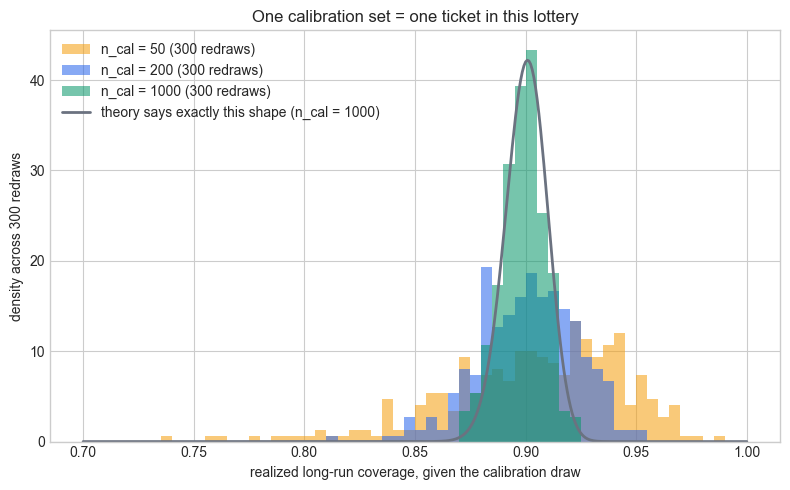

In [8]:
R_lottery = 300
X_test_pool, y_test_pool = simulate_hearthstone_listings(20_000, seed=RANDOM_SEED + 5)
test_scores = np.sort(np.abs(y_test_pool - model.predict(X_test_pool)))
m = len(test_scores)

# Recycle the 1,000,000 fresh scores from section 4: i.i.d. scores are i.i.d.
# however you slice them, so disjoint blocks act as independent calibration draws.
lottery = {}
start = 0
for n_cal in (50, 200, 1000):
    k_cal = math.ceil((n_cal + 1) * (1 - alpha))
    block = scores_pool[start:start + R_lottery * n_cal].reshape(R_lottery, n_cal)
    start += R_lottery * n_cal
    # per redraw, q_hat = the k-th smallest calibration score (the corrected quantile)
    q_hats = np.partition(block, k_cal - 1, axis=1)[:, k_cal - 1]
    # realized coverage of each draw = fraction of the test pool at or below its q_hat
    lottery[n_cal] = np.searchsorted(test_scores, q_hats, side="right") / m

for n_cal, cov in lottery.items():
    p5, p95 = np.percentile(cov, [5, 95])
    print(f"n_cal = {n_cal:>4}: mean realized coverage {cov.mean():.3f} | "
          f"5th-95th percentile of the lottery [{p5:.3f}, {p95:.3f}]")

fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(0.70, 1.0, 61)
for n_cal, color in [(50, AMBER), (200, BLUE), (1000, GREEN)]:
    ax.hist(lottery[n_cal], bins=bins, density=True, alpha=0.55, color=color,
            label=f"n_cal = {n_cal} (300 redraws)")
grid = np.linspace(0.70, 1.0, 400)
k1000 = math.ceil((1000 + 1) * (1 - alpha))
ax.plot(grid, stats.beta.pdf(grid, k1000, 1000 + 1 - k1000), color=GRAY, lw=2,
        label="theory says exactly this shape (n_cal = 1000)")
ax.set_title("One calibration set = one ticket in this lottery")
ax.set_xlabel("realized long-run coverage, given the calibration draw")
ax.set_ylabel("density across 300 redraws")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

Quote these numbers in your next capacity-planning meeting. With 50 calibration listings, the middle 90% of lottery tickets ranged from 0.828 to 0.958: a "90% system" that routinely ships as an 83% system or a 96% system, and you do not get to choose. With 200, the spread tightens to [0.865, 0.935]. With 1,000, it is [0.881, 0.913] — the rule of thumb from field guide §4 that roughly a thousand calibration points keep a 90% target typically within 0.88-0.92. The gray curve is not a fit; it is the parameter-free Beta density the rank argument predicts, and the green histogram traces it.

Two readings to avoid. First, the spread does not mean the guarantee failed: the means above sit at 0.903, 0.901, and 0.898 — centered where theory says. For `n_cal = 50` the center is genuinely a touch above 0.90, since $k/(n+1) = 46/51 = 0.902$; the 0.898 is our finite test pool talking — grading all 300 redraws against the same 20,000 listings shares one measurement wobble of about ±0.002 across the whole column. Second, do not conclude that coverage must be re-measured hourly in production; the lesson is to *size the calibration set deliberately* and to quote realized coverage with its expected spread, not as a point value. More calibration data narrows the lottery; nothing else does.

## 6. Marginal, not conditional

The guarantee we have been demonstrating is **marginal coverage**: 90% *averaged over everything* — all listings, all neighborhoods, all difficulty levels. What stakeholders usually imagine is **conditional coverage**: 90% *for each kind of listing separately* — every neighborhood, every price band, every size. Conformal prediction guarantees the first. It does not, and provably cannot (distribution-free, with finite intervals), guarantee the second. Notebook 05 closes most of the practical gap; this section makes sure you feel why the gap exists (field guide §3).

The construction is the classic two-group example from Angelopoulos and Bates, made concrete. One metro area: 90% of listings sit in a quiet suburb where prices hug the trend line, 10% sit on a wild riverfront where prices swing 2.2 times harder. Same average price line in both — the model can learn the mean perfectly well; it even gets the neighborhood as a feature. The one thing it cannot do with an absolute-residual score is hand out different interval widths, and that is where the bodies are buried.

In [9]:
def simulate_two_neighborhoods(n, seed):
    """Listings from one metro: 90% quiet suburb, 10% wild riverfront.

    Both neighborhoods share the SAME average price line - a model can learn
    the mean equally well for both, and it is even told which neighborhood
    each listing is in. What differs is the spread around the line:
    riverfront sale prices swing 2.2x harder than suburb prices.
    Same mean, different noise: the classic setup where one interval width
    cannot serve both slices.

    Returns X (n x 2: size_m2, is_riverfront), price ($1000s), riverfront mask.
    """
    rng = np.random.default_rng(seed)
    riverfront = rng.random(n) < 0.10
    size = rng.uniform(50.0, 250.0, size=n)
    noise_sd = np.where(riverfront, 66.0, 30.0)
    price = 40.0 + 2.2 * size + rng.normal(0.0, 1.0, size=n) * noise_sd
    X = np.column_stack([size, riverfront.astype(float)])
    return X, price, riverfront


X_nbhd, y_nbhd, river = simulate_two_neighborhoods(23_000, seed=RANDOM_SEED + 6)
X_tr, y_tr = X_nbhd[:2_000], y_nbhd[:2_000]
X_cal, y_cal = X_nbhd[2_000:3_000], y_nbhd[2_000:3_000]
X_te, y_te, river_te = X_nbhd[3_000:], y_nbhd[3_000:], river[3_000:]

nbhd_model = GradientBoostingRegressor(random_state=RANDOM_SEED).fit(X_tr, y_tr)

scores = np.abs(y_cal - nbhd_model.predict(X_cal))
n = len(scores)
q_level = math.ceil((n + 1) * (1 - alpha)) / n
assert q_level <= 1.0, "Calibration set too small for this alpha - the honest interval is infinite (field guide §1)"
q_hat = np.quantile(scores, q_level, method="higher")

pred_te = nbhd_model.predict(X_te)
covered = np.abs(y_te - pred_te) <= q_hat

print(f"q_hat = {q_hat:.1f}k$ -> every listing gets the same interval: prediction +/- {q_hat:.1f}k$")
print(f"overall test coverage: {covered.mean():.3f} (target {1 - alpha:.2f}, on {len(y_te):,} listings)")

slice_table = (
    pd.DataFrame({"neighborhood": np.where(river_te, "riverfront", "suburb"),
                  "covered": covered})
    .groupby("neighborhood")["covered"]
    .agg(listings="size", coverage="mean")
    .reset_index()
)
slice_table["interval_width_k$"] = 2 * q_hat
slice_table.round(3)

q_hat = 56.4k$ -> every listing gets the same interval: prediction +/- 56.4k$
overall test coverage: 0.897 (target 0.90, on 20,000 listings)


,neighborhood,listings,coverage,interval_width_k$
0,riverfront,1956,0.586,112.786
1,suburb,18044,0.930,112.786


Overall coverage: 0.897. Green dashboard, promise kept — marginally. Now read the slice table: the suburb enjoys 0.930 while the riverfront gets 0.586. Same system, same quarter, same "90% guarantee". The arithmetic is brutal and simple: 90% of listings are suburban, so $0.9 \times 0.93 + 0.1 \times 0.59 \approx 0.90$, and the average washes the riverfront's failure out of sight. The interval width column rubs it in — the same 56.4k of padding on either side of every prediction, a band 113k dollars wide that over-serves the calm suburb and badly under-serves the riverfront.

What this does NOT mean: conformal prediction did not malfunction, and nobody lied. The promise made was marginal, and marginal is what was delivered. The failure is in *which promise was bought*. If the riverfront desk matters on its own — and any slice that appears in a contract, a regulation, or a support queue does — you must check its coverage separately, and then fix it with tools built for the job: per-group calibration (notebook 04 does it for classes) or scores that adapt their width to difficulty (notebook 05).

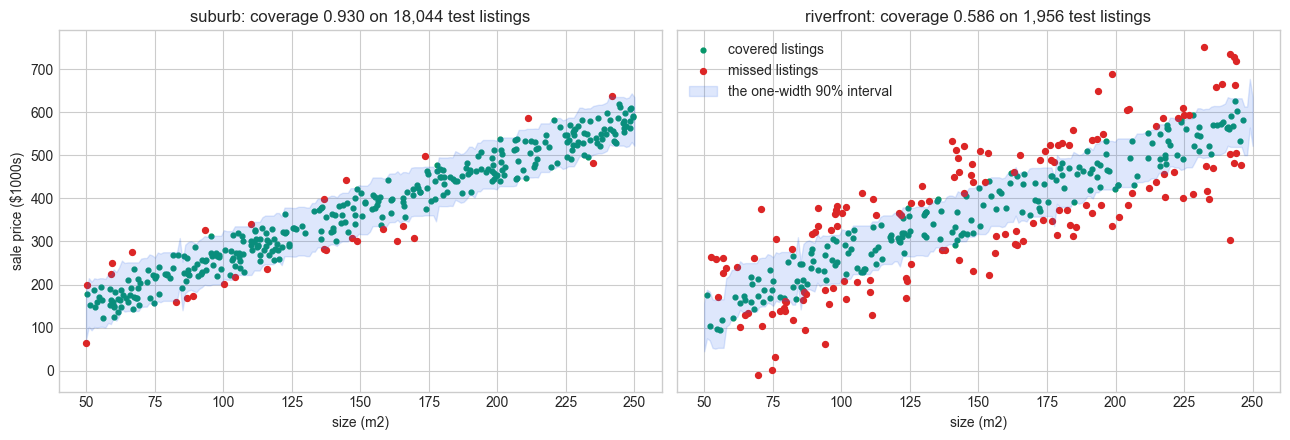

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
size_grid = np.linspace(50.0, 250.0, 200)
for ax, flag, name in [(axes[0], 0.0, "suburb"), (axes[1], 1.0, "riverfront")]:
    mask = river_te == bool(flag)
    idx = np.flatnonzero(mask)[:350]  # a readable sample of test listings
    hit = covered[idx]
    ax.scatter(X_te[idx][hit, 0], y_te[idx][hit], s=12, color=GREEN, label="covered listings")
    ax.scatter(X_te[idx][~hit, 0], y_te[idx][~hit], s=18, color=RED, label="missed listings")
    band_center = nbhd_model.predict(np.column_stack([size_grid, np.full_like(size_grid, flag)]))
    ax.fill_between(size_grid, band_center - q_hat, band_center + q_hat,
                    color=BLUE, alpha=0.15, label="the one-width 90% interval")
    ax.set_title(f"{name}: coverage {covered[mask].mean():.3f} on {mask.sum():,} test listings")
    ax.set_xlabel("size (m2)")
axes[0].set_ylabel("sale price ($1000s)")
axes[1].legend(loc="upper left")
plt.tight_layout()
plt.show()

The picture says it faster than the table: the band has one width everywhere — a property of the absolute-residual score, not of conformal prediction itself — so the quiet suburb sits comfortably inside it while riverfront listings spill above and below in red. Averages hide slices. Always cut coverage by the slices your business actually answers for.

## 7. Breaking the machine on purpose

Every proof in this notebook leaned on one load-bearing wall: the calibration and test rows are exchangeable — anonymous tiles from one shaken bag. Nothing checks that assumption at runtime. No exception is raised when it fails. The coverage just quietly rots (field guide §6). So let us fail it ourselves, with the single most ordinary mistake in applied data science: splitting a sorted file by row position.

The setup mimics a lazy pipeline. Riverton listings arrive in a CSV that happens to be sorted — here by `size_m2`; in real life it is usually by date, which is worse because you cannot re-shuffle time. We take rows 1-2000 for training (the small homes), rows 2001-3000 for calibration (the mid-sized homes), and rows 3001-4000 for testing (the large homes). Then we do the identical experiment with the rows shuffled first. Same data, same model class, same corrected quantile — only the ordering changes.

In [11]:
X_river, y_river = simulate_hearthstone_listings(4_000, seed=RANDOM_SEED + 7)

def coverage_with_row_order(order, label):
    """Split conformal on riverton listings under a given row ordering.

    Rows 0-1999 train, rows 2000-2999 calibrate, rows 3000-3999 test.
    Same listings, same model class, same corrected quantile - the ONLY
    thing that changes between calls is which listings land in which role.
    """
    X_ord, y_ord = X_river[order], y_river[order]
    fit = GradientBoostingRegressor(random_state=RANDOM_SEED).fit(X_ord[:2_000], y_ord[:2_000])
    scores = np.abs(y_ord[2_000:3_000] - fit.predict(X_ord[2_000:3_000]))
    n = len(scores)
    q_level = math.ceil((n + 1) * (1 - alpha)) / n
    q_hat = np.quantile(scores, q_level, method="higher")
    covered = np.abs(y_ord[3_000:] - fit.predict(X_ord[3_000:])) <= q_hat
    print(f"{label:<32} q_hat = {q_hat:6.1f}k$ | test coverage = {covered.mean():.3f}")


coverage_with_row_order(np.argsort(X_river[:, 0]), "sorted by size_m2 (broken):")
rng = np.random.default_rng(RANDOM_SEED + 8)
coverage_with_row_order(rng.permutation(4_000), "shuffled (exchangeable):")

sorted by size_m2 (broken):      q_hat =  280.0k$ | test coverage = 0.680
shuffled (exchangeable):         q_hat =  268.8k$ | test coverage = 0.919


Coverage craters to 0.680 on the sorted split — a "90% system" missing one listing in three — and snaps back to 0.919 the moment the rows are shuffled (with a 1,000-listing test set and a single calibration draw, ±0.02 of wobble around 0.90 is expected; sections 3 and 5 told you exactly how much). The sorted split's `q_hat` deserves a careful reading: at 280.0k it is even *wider* than the honest run's 268.8k, and it still misses 32% of listings — the worst of both worlds. The model, trained only on small homes, was already wrong on the mid-sized calibration homes, so the threshold inflated; but the large test homes sit further out still, where the simulator makes prices noisier *and* the model is extrapolating beyond every size it trained on, so the calibration scores understate the test scores no matter how wide they push the band. The test scores are not peers of the calibration scores; the bag was never shaken; the flat histogram of section 2 never had a chance.

This exact failure has a famous real-world fingerprint. Shafer and Vovk ran a conformal predictor promising 5% errors over the USPS handwritten-digit dataset in its natural order, and it delivered 5% on the training portion and 8% on the test portion — because the test batch had been collected differently and the sequence was not exchangeable. On a random permutation of the same dataset, errors ran at almost exactly the promised 5%. The math does exactly what it says, no more: shuffle the bag and the guarantee is restored by construction; leave real-world ordering in place and the guarantee applies to a bag that does not exist.

One caution before you over-learn this lesson: "shuffle everything" is only a cure when the world itself is not drifting. If your deployment market genuinely differs from your calibration market — new region, new season — no shuffle of old data fixes that. One specific, common version of this (the input mix shifts while the price-given-features relationship holds) can actually be repaired, with weights instead of shuffles: that is notebook 07.

## 8. What we did NOT prove

A guarantee is only trustworthy if you can state where it stops. Three honest limits, all demonstrated in this very notebook:

- **No per-house probability.** Nothing here lets us say "this interval covers THIS house with probability 90%." The 90% belongs to the procedure before the data arrive, not to any one computed interval afterwards — and per-input coverage is not a missing feature but a proven impossibility: any distribution-free method that promised it would be forced into infinitely wide intervals (Lei and Wasserman's theorem, long flagged by Vovk). Coverage is a batting average, not a promise about this at-bat.
- **Marginal only, never conditional.** Section 6's riverfront sat at 0.586 while the dashboard read 0.897. Both numbers are consistent with everything we proved. If a slice matters, measure it, then reach for per-group calibration (notebook 04) or adaptive scores (notebook 05).
- **Test-set errors are not independent coin flips.** With one fixed calibration set, every test prediction leans on the same `q_hat`; if your calibration draw was unlucky, you miss more than 10% all quarter. That shared dependence is precisely the section-5 lottery — the guarantee averages over calibration draws, while your deployment rides a single ticket.

## 9. Common mistakes to avoid

1. **Using `np.quantile(scores, 0.9)` as the threshold.** The naive quantile delivered 0.8915 where the corrected rule delivered 0.8998 (section 3), and the gap widens as the calibration set shrinks. Always `math.ceil((n + 1) * (1 - alpha)) / n` with `method="higher"` (field guide §1).
2. **Calibrating on training residuals.** The leaderboard argument requires the model to be a fixed spectator that never saw the scored rows; training residuals violate the premise, not just the etiquette (field guide §2, committed live in notebook 01).
3. **Quoting "90% probability" on a single offer.** Section 8, first bullet: the number describes the procedure's long-run batting average, not any one interval. Phrase it as an error budget across offers.
4. **Shipping on the overall coverage number alone.** Our 0.897 overall concealed a 0.586 riverfront (section 6). Print the coverage-by-slice table for every slice someone answers for (field guide §3).
5. **Skimping on calibration data.** With 50 calibration points the realized-coverage lottery spanned [0.828, 0.958]; with 1,000 it spanned [0.881, 0.913] (section 5). Size the calibration set to the tolerance you can defend (field guide §4).
6. **Splitting a sorted file by row position.** Coverage 0.680 versus 0.919 on identical data (section 7), and no error message either way. Shuffle before splitting, and treat any deliberate ordering in the pipeline as a red flag (field guide §6).

## 10. What to say in the business review

> **Strong version:** "The interval system misses about one offer in ten over the long run. That error budget holds for any pricing model we swap in — it comes from a rank argument, not from trusting the model — provided the listings we price look like the listings we calibrated on and were never used in training. With our 1,000-listing calibration set, realized coverage typically lands between 0.88 and 0.92, and we monitor it per neighborhood, because the 90% is an average and averages hide slices."

> **Weak version:** "Every offer we send has a 90% chance of being right, so the riverfront desk can count on 90% too."

The weak version makes three claims this notebook disproved in code: a per-offer probability (section 8), a per-slice guarantee (section 6, riverfront at 0.586), and an unconditional one — it silently assumes the market we deploy in matches the market we calibrated on (section 7, coverage 0.680 when it did not).

### The one-line summary

We watched the guarantee emerge from a flat histogram of ranks: a newcomer among $n$ exchangeable peers is equally likely to hold any of the $n+1$ positions, so the $\lceil (n+1)(1-\alpha) \rceil$-th smallest calibration score covers it at least $1-\alpha$ of the time — for any model, any market, any ugly distribution — while everything the promise does not say (your draw's lottery ticket, your hardest slice, your sorted file) was demonstrated just as concretely.

The guarantee is a statement about ranks among shuffled peers — and ranks do not know what a house is.